# Exploración del clima histórico de ciudades de India

Análisis del tamaño, la completitud y el perfil climático mensual por ciudad.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ruta_datos = r"C:/Users/aaran/Downloads/Datasets/RNN/Weather/india_multicity_historical_climate.csv"
df = pd.read_csv(ruta_datos, parse_dates=["date"])
df.head()

,city,state,latitude,longitude,date,year,month,day_of_year,decade,weather_code,...,is_monsoon_season,heatwave_day_simple_flag,sunshine_duration_sec,daylight_duration_sec,wind_speed_max_kmh,wind_gusts_max_kmh,wind_direction_dominant_deg,solar_radiation_mj_m2,reference_evapotranspiration_mm,has_missing_values
0,Agartala,Tripura,23.8315,91.2868,1940-01-01,1940,1,1,1940,3,...,False,False,NaN,38513.08,8.8,18.7,NaN,NaN,NaN,True
1,Agartala,Tripura,23.8315,91.2868,1940-01-02,1940,1,2,1940,3,...,False,False,36000.0,38533.86,8.8,18.7,16.0,16.50,3.31,False
2,Agartala,Tripura,23.8315,91.2868,1940-01-03,1940,1,3,1940,2,...,False,False,36000.0,38556.39,9.0,20.5,8.0,16.30,3.33,False
3,Agartala,Tripura,23.8315,91.2868,1940-01-04,1940,1,4,1940,3,...,False,False,36000.0,38580.65,9.8,23.8,8.0,16.89,3.54,False
4,Agartala,Tripura,23.8315,91.2868,1940-01-05,1940,1,5,1940,2,...,False,False,36000.0,38606.60,9.8,23.4,13.0,16.93,3.56,False


## 1. Cantidad de filas y columnas

In [31]:
n_filas, n_columnas = df.shape
print(f"Cantidad de filas: {n_filas:,}")
print(f"Cantidad de columnas: {n_columnas}")

Cantidad de filas: 1,581,050
Cantidad de columnas: 29


## 2. Balance de datos por columna

Se comparan los porcentajes de valores presentes y ausentes.

In [32]:
balance_columnas = pd.DataFrame({
    "presentes": df.notna().sum(),
    "ausentes": df.isna().sum()
})
balance_columnas["porcentaje_presente"] = balance_columnas["presentes"] / len(df) * 100
balance_columnas["porcentaje_ausente"] = balance_columnas["ausentes"] / len(df) * 100
balance_columnas.sort_values("porcentaje_ausente", ascending=False)

,presentes,ausentes,porcentaje_presente,porcentaje_ausente
wind_direction_dominant_deg,1581000,50,99.996838,0.003162
sunshine_duration_sec,1581000,50,99.996838,0.003162
snowfall_cm,1581000,50,99.996838,0.003162
precipitation_mm,1581000,50,99.996838,0.003162
rain_mm,1581000,50,99.996838,0.003162
solar_radiation_mj_m2,1581000,50,99.996838,0.003162
reference_evapotranspiration_mm,1581000,50,99.996838,0.003162
temp_range_c,1581049,1,99.999937,0.000063
temp_min_c,1581049,1,99.999937,0.000063
date,1581050,0,100.000000,0.000000


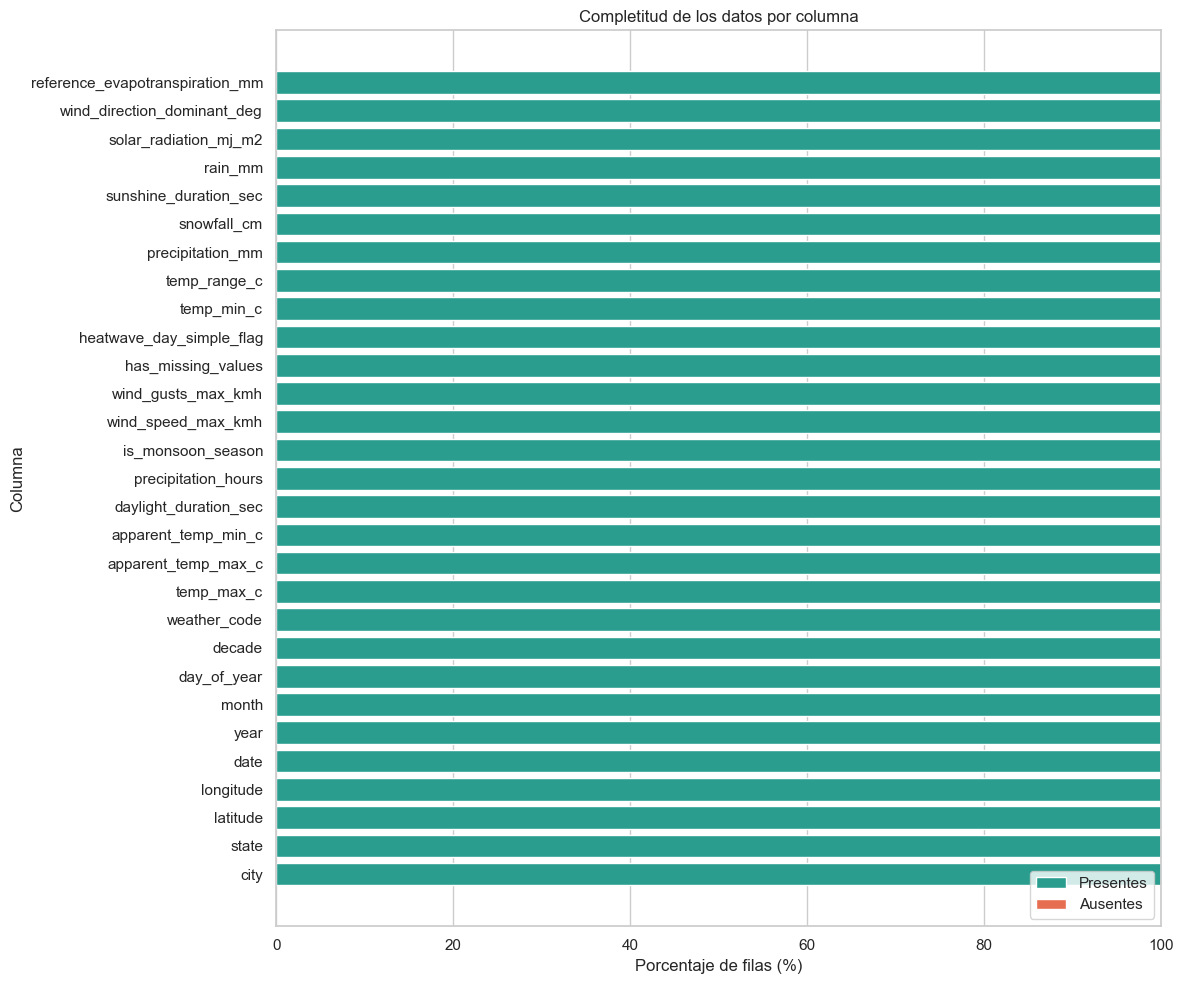

In [33]:
balance_ordenado = balance_columnas.sort_values("porcentaje_ausente")
fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(balance_ordenado.index, balance_ordenado["porcentaje_presente"], color="#2A9D8F", label="Presentes")
ax.barh(balance_ordenado.index, balance_ordenado["porcentaje_ausente"], left=balance_ordenado["porcentaje_presente"], color="#E76F51", label="Ausentes")
ax.set(xlim=(0, 100), xlabel="Porcentaje de filas (%)", ylabel="Columna", title="Completitud de los datos por columna")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 3. Clima de cada ciudad

Se resume cada ciudad por mes usando todos los años. La temperatura media diaria se aproxima promediando las temperaturas máxima y mínima.

In [34]:
df["temp_media_c"] = (df["temp_max_c"] + df["temp_min_c"]) / 2
clima_mensual = (
    df.groupby(["city", "month"], as_index=False)
      .agg(temperatura_media_c=("temp_media_c", "mean"),
           precipitacion_media_mm=("precipitation_mm", "mean"),
           dias_observados=("date", "count"))
)
clima_mensual.head(12)

,city,month,temperatura_media_c,precipitacion_media_mm,dias_observados
0,Agartala,1,18.895050,0.282233,2697
1,Agartala,2,21.776526,0.832221,2458
2,Agartala,3,26.015165,2.656804,2697
3,Agartala,4,28.016686,7.332989,2610
4,Agartala,5,28.423823,10.978346,2697
5,Agartala,6,28.438678,11.465402,2610
6,Agartala,7,28.227339,9.513474,2694
7,Agartala,8,28.334134,7.983346,2666
8,Agartala,9,28.167093,7.655775,2580
9,Agartala,10,26.816954,5.114966,2666


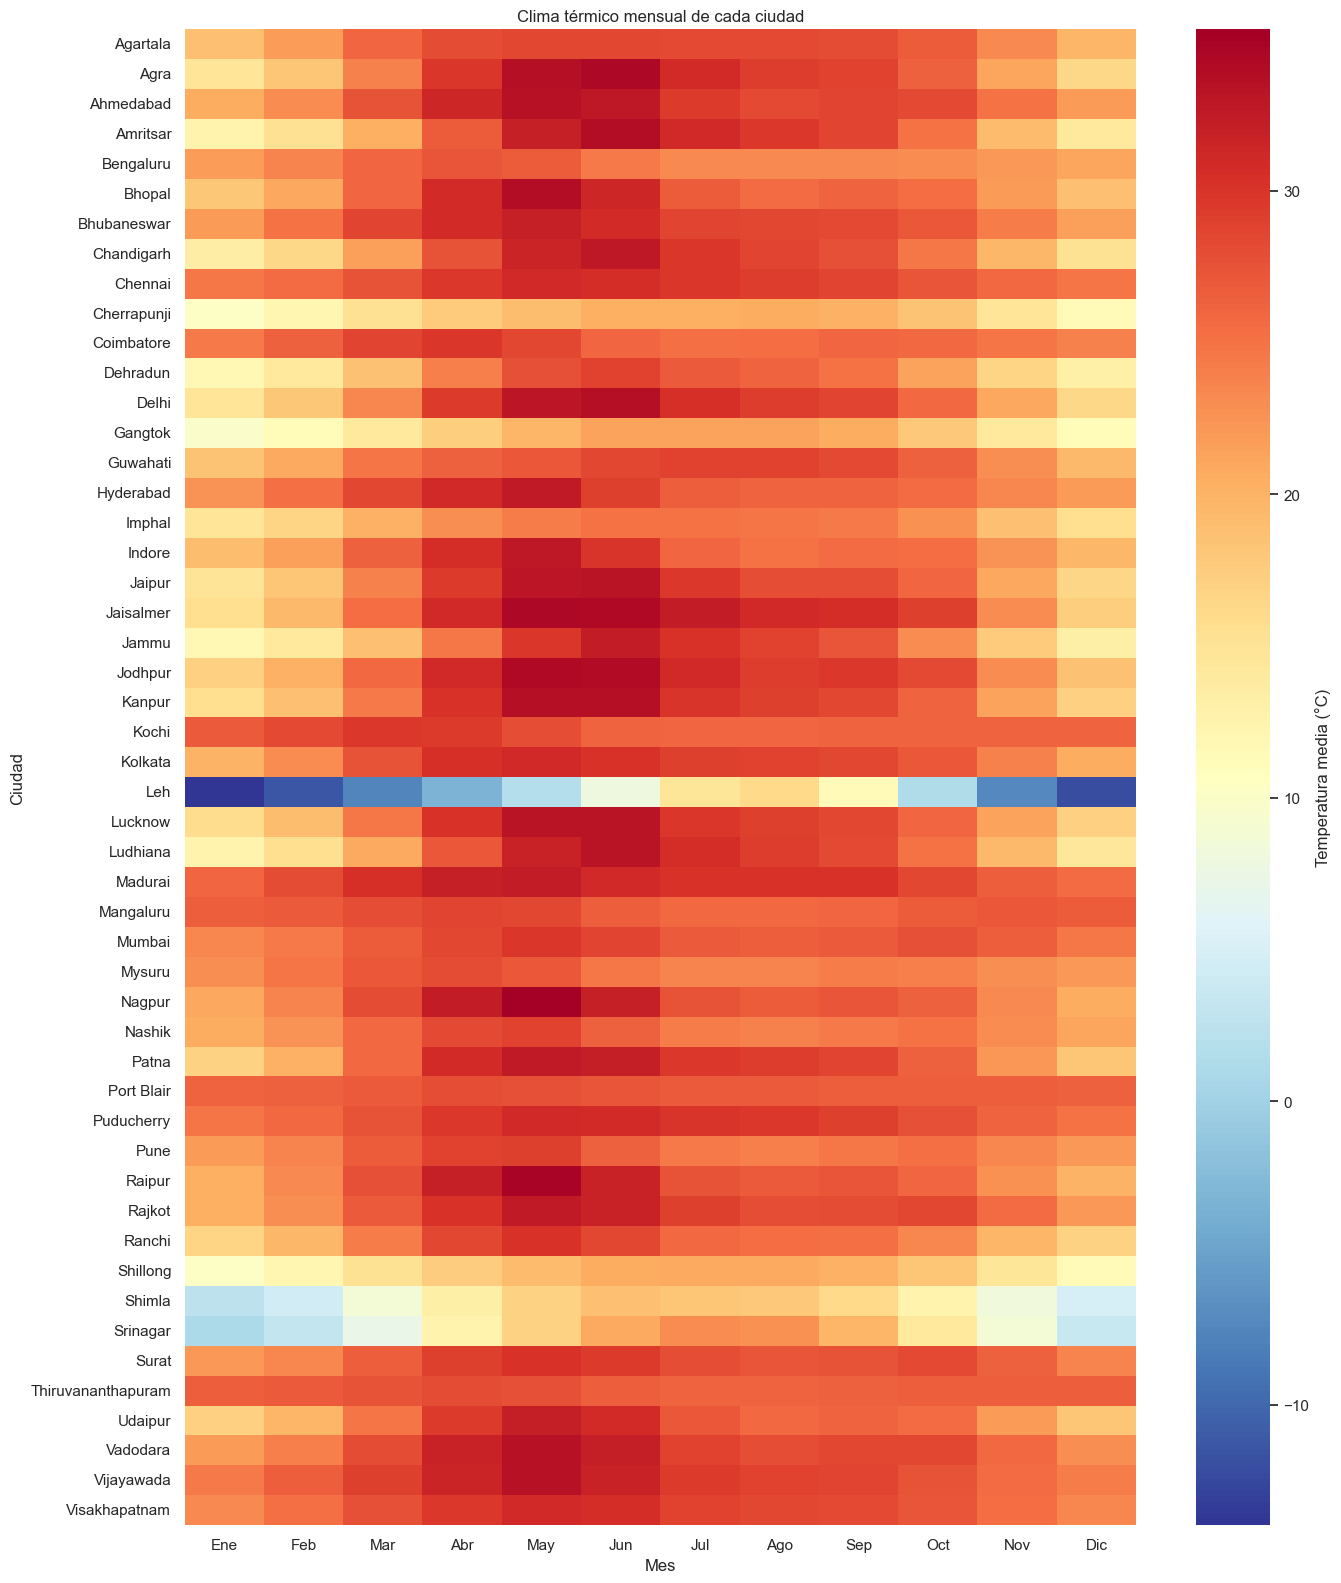

In [35]:
nombres_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
temperatura_ciudad = clima_mensual.pivot(index="city", columns="month", values="temperatura_media_c").reindex(columns=range(1, 13))
temperatura_ciudad.columns = nombres_meses
plt.figure(figsize=(14, max(8, len(temperatura_ciudad) * 0.32)))
sns.heatmap(temperatura_ciudad, cmap="RdYlBu_r", cbar_kws={"label": "Temperatura media (°C)"})
plt.title("Clima térmico mensual de cada ciudad")
plt.xlabel("Mes"); plt.ylabel("Ciudad")
plt.tight_layout(); plt.show()

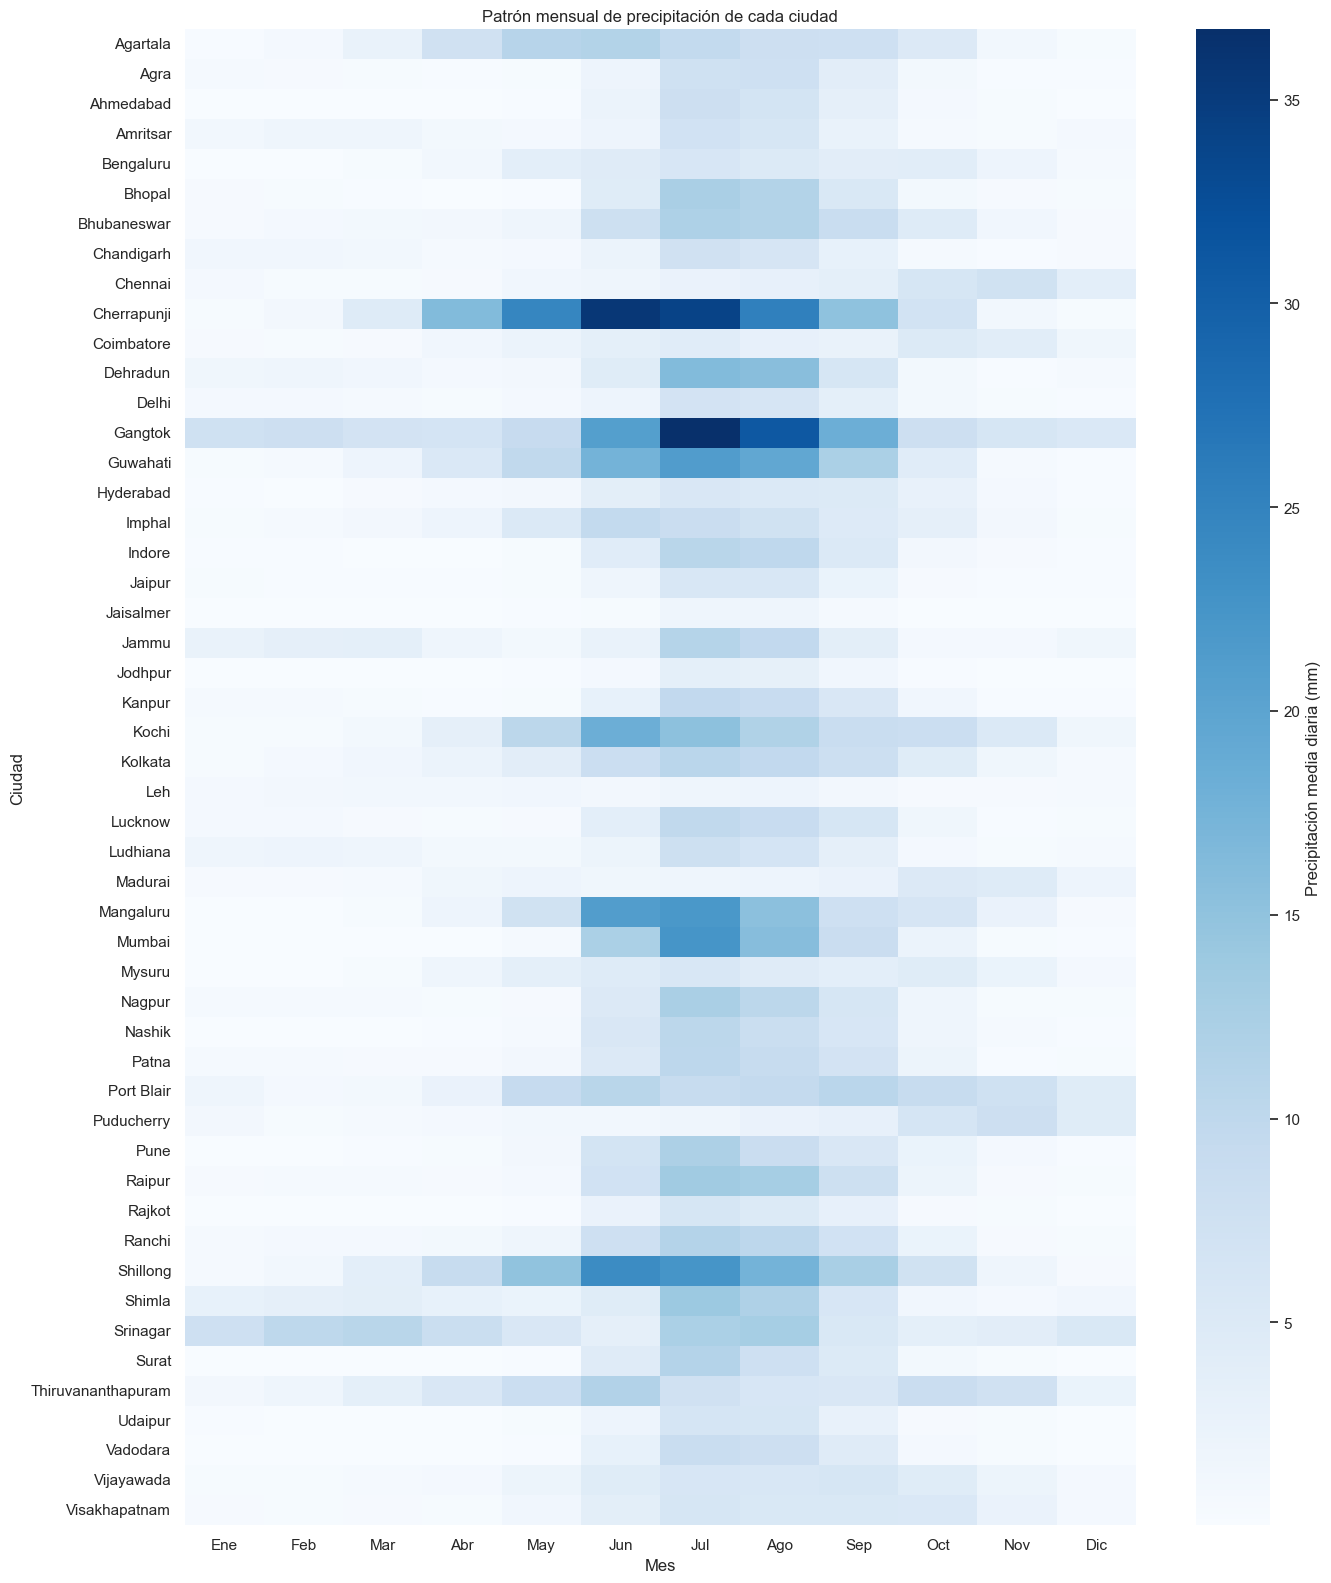

In [36]:
precipitacion_ciudad = clima_mensual.pivot(index="city", columns="month", values="precipitacion_media_mm").reindex(columns=range(1, 13))
precipitacion_ciudad.columns = nombres_meses
plt.figure(figsize=(14, max(8, len(precipitacion_ciudad) * 0.32)))
sns.heatmap(precipitacion_ciudad, cmap="Blues", cbar_kws={"label": "Precipitación media diaria (mm)"})
plt.title("Patrón mensual de precipitación de cada ciudad")
plt.xlabel("Mes"); plt.ylabel("Ciudad")
plt.tight_layout(); plt.show()

# RNN simple: temperatura máxima de Delhi

El primer modelo utiliza los últimos 30 días de temperatura máxima para predecir la temperatura máxima del día siguiente. Se conserva el estilo de `example_RNN.ipynb` usando PyTorch, `Dataset`, `DataLoader`, una clase de modelo y funciones `fit` y `predict`.

## 4. Subconjunto de datos de Delhi

In [37]:
# En el CSV la ciudad está registrada como "Delhi".
df_delhi = (
    df.loc[df["city"].str.strip().str.casefold().eq("delhi")]
      .sort_values("date")
      .reset_index(drop=True)
      .copy()
)

print(f"Instancias disponibles para Delhi: {len(df_delhi):,}")
print(f"Periodo: {df_delhi['date'].min().date()} a {df_delhi['date'].max().date()}")
print(f"Columnas conservadas: {df_delhi.shape[1]}")
df_delhi.head()

Instancias disponibles para Delhi: 31,621
Periodo: 1940-01-01 a 2026-07-28
Columnas conservadas: 30


,city,state,latitude,longitude,date,year,month,day_of_year,decade,weather_code,...,heatwave_day_simple_flag,sunshine_duration_sec,daylight_duration_sec,wind_speed_max_kmh,wind_gusts_max_kmh,wind_direction_dominant_deg,solar_radiation_mj_m2,reference_evapotranspiration_mm,has_missing_values,temp_media_c
0,Delhi,Delhi,28.6139,77.209,1940-01-01,1940,1,1,1940,2,...,False,NaN,39965.72,14.1,28.8,NaN,NaN,NaN,True,18.40
1,Delhi,Delhi,28.6139,77.209,1940-01-02,1940,1,2,1940,0,...,False,38381.11,39980.42,13.5,31.7,122.0,19.26,4.08,False,19.80
2,Delhi,Delhi,28.6139,77.209,1940-01-03,1940,1,3,1940,3,...,False,38275.13,39996.37,13.6,32.0,118.0,18.79,3.90,False,19.95
3,Delhi,Delhi,28.6139,77.209,1940-01-04,1940,1,4,1940,3,...,False,38341.08,40013.54,12.8,30.6,116.0,19.64,4.12,False,19.60
4,Delhi,Delhi,28.6139,77.209,1940-01-05,1940,1,5,1940,0,...,False,38482.26,40031.91,12.2,30.2,129.0,19.76,4.10,False,19.65


### Últimos diez días registrados de Delhi

In [38]:
# Explorador tabular: diez observaciones más recientes, ordenadas de la más antigua a la más nueva.
columnas_ultimos_dias = [
    "date", "temp_max_c", "temp_min_c", "precipitation_mm",
    "rain_mm", "weather_code", "wind_speed_max_kmh",
    "is_monsoon_season", "heatwave_day_simple_flag", "has_missing_values"
]

ultimos_10_dias_delhi = (
    df_delhi.nlargest(10, "date")
            .sort_values("date")
            [columnas_ultimos_dias]
            .reset_index(drop=True)
)

print(f"Última fecha registrada: {ultimos_10_dias_delhi['date'].max().date()}")
ultimos_10_dias_delhi

Última fecha registrada: 2026-07-28


,date,temp_max_c,temp_min_c,precipitation_mm,rain_mm,weather_code,wind_speed_max_kmh,is_monsoon_season,heatwave_day_simple_flag,has_missing_values
0,2026-07-19,35.2,30.1,1.5,1.5,53,10.4,True,False,False
1,2026-07-20,30.8,27.8,8.5,8.5,61,10.0,True,False,False
2,2026-07-21,30.0,26.5,25.0,25.0,63,14.9,True,False,False
3,2026-07-22,32.8,27.1,5.4,5.4,61,18.2,True,False,False
4,2026-07-23,33.0,27.9,5.9,5.9,63,18.3,True,False,False
5,2026-07-24,32.5,27.7,1.6,1.6,51,19.9,True,False,False
6,2026-07-25,33.4,28.1,6.2,6.2,61,16.9,True,False,False
7,2026-07-26,35.3,28.4,1.1,1.1,53,9.8,True,False,False
8,2026-07-27,36.0,29.3,7.8,7.8,63,13.9,True,False,False
9,2026-07-28,30.3,27.1,22.6,22.6,63,12.6,True,False,False


## 5. Todas las features de Delhi

Para que décadas de datos sean legibles, las variables numéricas y booleanas se agregan por mes. Las columnas identificadoras `city`, `state` y `date` no se grafican como magnitudes.

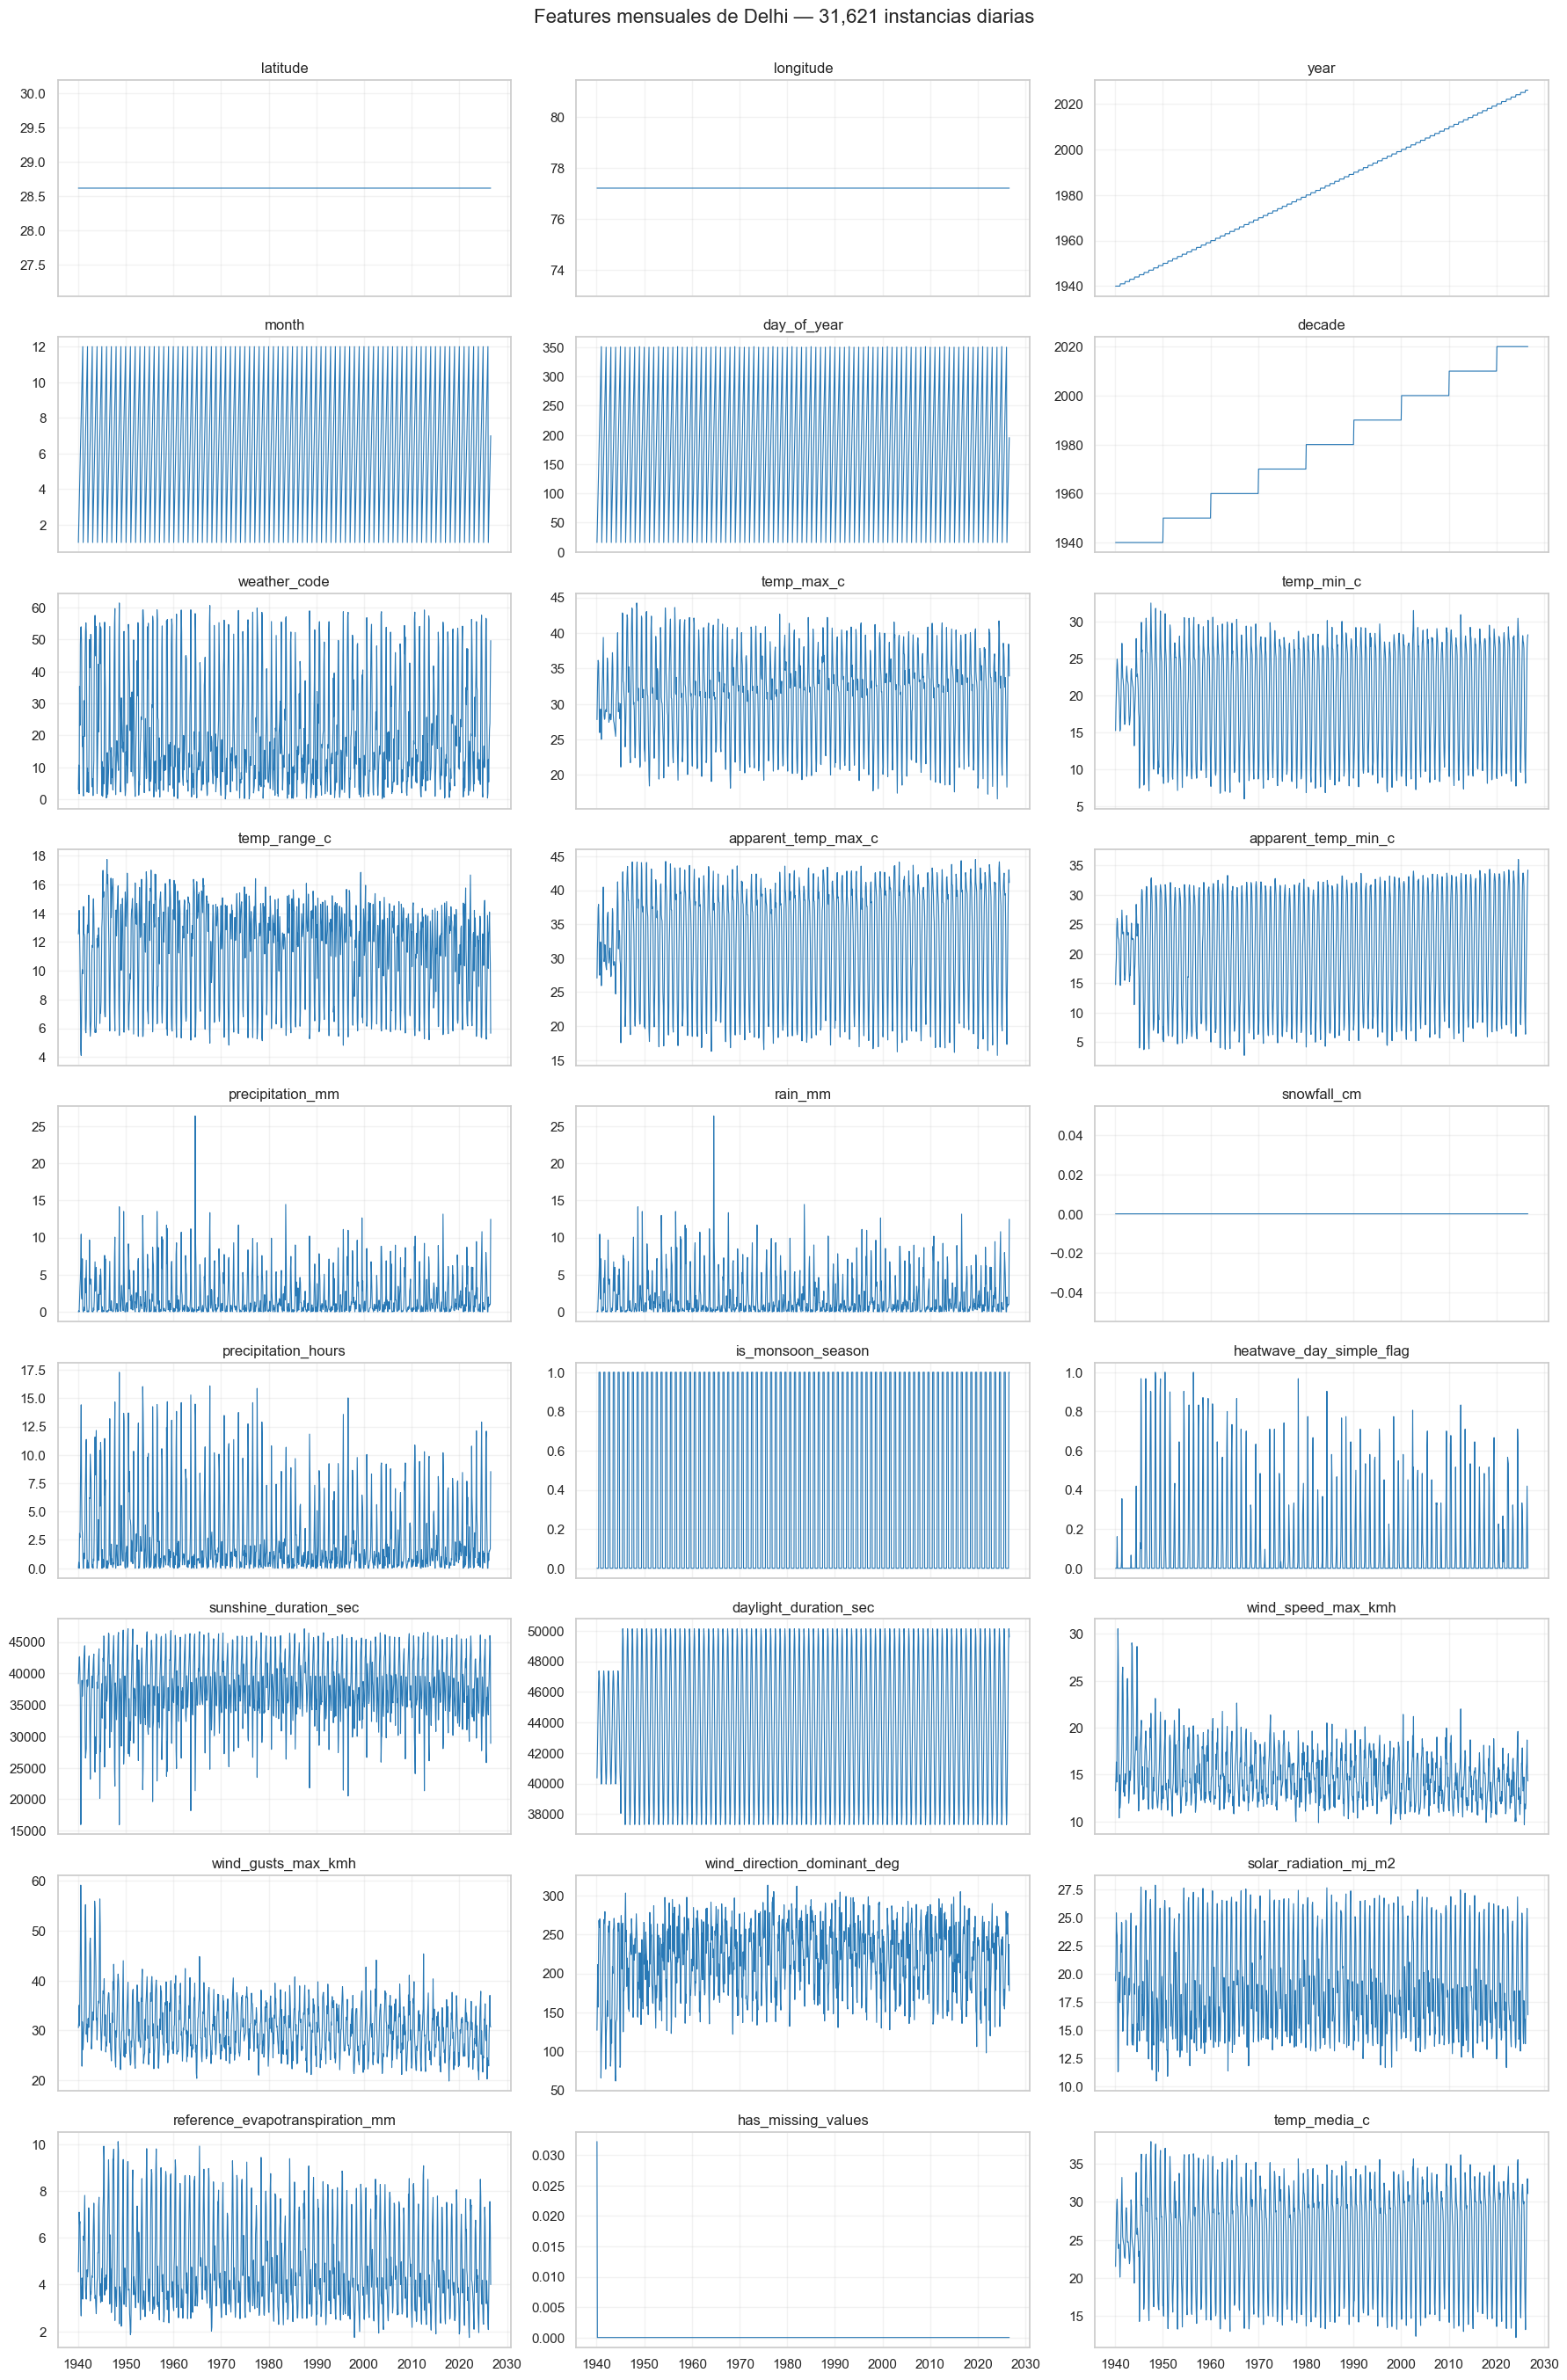

In [39]:
features_graficables = df_delhi.select_dtypes(include=["number", "bool"]).columns.tolist()
datos_grafica = (
    df_delhi.set_index("date")[features_graficables]
            .resample("ME").mean()
)

n_cols = 3
n_rows = (len(features_graficables) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
axes = axes.flatten()

for ax, feature in zip(axes, features_graficables):
    ax.plot(datos_grafica.index, datos_grafica[feature], linewidth=0.8, color="#2878B5")
    ax.set_title(feature)
    ax.grid(alpha=0.25)

for ax in axes[len(features_graficables):]:
    ax.remove()

fig.suptitle(f"Features mensuales de Delhi — {len(df_delhi):,} instancias diarias", fontsize=16, y=1.002)
plt.tight_layout()
plt.show()

## 6. Serie temporal y división cronológica

La división mantiene el orden temporal: 70% entrenamiento, 15% validación y 15% prueba. Se aplica una normalización Min-Max calculada únicamente con entrenamiento. Las entradas contienen 30 días consecutivos y el objetivo es el valor del día 31.

In [40]:
import numpy as np
serie_delhi = (
    df_delhi[["date", "temp_max_c"]]
      .dropna()
      .drop_duplicates(subset="date", keep="last")
      .sort_values("date")
      .reset_index(drop=True)
)

n_total = len(serie_delhi)
fin_train = int(n_total * 0.70)
fin_valid = int(n_total * 0.85)

valores_temperatura = serie_delhi["temp_max_c"].to_numpy(dtype=np.float32)

# Normalización Min-Max usando solamente el conjunto de entrenamiento.
temp_min_train = valores_temperatura[:fin_train].min()
temp_max_train = valores_temperatura[:fin_train].max()
rango_temp_train = temp_max_train - temp_min_train

def normalizar_temperatura(valores):
    return ((valores - temp_min_train) / rango_temp_train).astype(np.float32)

def desnormalizar_temperatura(valores):
    return np.asarray(valores) * rango_temp_train + temp_min_train

valores_normalizados = normalizar_temperatura(valores_temperatura)
print(f"Rango de train usado para normalizar: {temp_min_train:.1f} °C a {temp_max_train:.1f} °C")

print(f"Train: {fin_train:,} días")
print(f"Validación: {fin_valid - fin_train:,} días")
print(f"Test: {n_total - fin_valid:,} días")

Rango de train usado para normalizar: 13.1 °C a 47.0 °C
Train: 22,134 días
Validación: 4,743 días
Test: 4,744 días


In [41]:
n_steps = 30

# Ventanas consecutivas creadas sobre la serie normalizada.
ventanas = np.lib.stride_tricks.sliding_window_view(valores_normalizados, n_steps + 1)
X = ventanas[:, :-1, np.newaxis].copy().astype(np.float32)
Y = ventanas[:, -1, np.newaxis].copy().astype(np.float32)
fechas_y = serie_delhi["date"].iloc[n_steps:].to_numpy()
indices_objetivo = np.arange(n_steps, n_total)
mask_train = indices_objetivo < fin_train
mask_valid = (indices_objetivo >= fin_train) & (indices_objetivo < fin_valid)
mask_test = indices_objetivo >= fin_valid

X_train, Y_train = X[mask_train], Y[mask_train]
X_valid, Y_valid = X[mask_valid], Y[mask_valid]
X_test, Y_test = X[mask_test], Y[mask_test]
fechas_test = fechas_y[mask_test]

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_valid:", X_valid.shape, "Y_valid:", Y_valid.shape)
print("X_test: ", X_test.shape,  "Y_test: ", Y_test.shape)

X_train: (22104, 30, 1) Y_train: (22104, 1)
X_valid: (4743, 30, 1) Y_valid: (4743, 1)
X_test:  (4744, 30, 1) Y_test:  (4744, 1)


## 7. Dataset y DataLoader

In [42]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
  def __init__(self, X, y=None, train=True):
    self.X = X
    self.y = y
    self.train = train

  def __len__(self):
    return len(self.X)

  def __getitem__(self, ix):
    if self.train:
      return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
    return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, Y_train),
    'eval': TimeSeriesDataset(X_valid, Y_valid),
    'test': TimeSeriesDataset(X_test, Y_test, train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True, batch_size=64),
    'eval': DataLoader(dataset['eval'], shuffle=False, batch_size=64),
    'test': DataLoader(dataset['test'], shuffle=False, batch_size=64)
}

## 8. RNN simple y entrenamiento

In [43]:
class SimpleRNN(torch.nn.Module):
  def __init__(self, input_size=1, hidden_size=20, num_layers=2):
    super().__init__()
    self.rnn = torch.nn.RNN(
        input_size=input_size, hidden_size=hidden_size,
        num_layers=num_layers, batch_first=True
    )
    self.fc = torch.nn.Linear(hidden_size, 1)

  def forward(self, x):
    x, h = self.rnn(x)
    # Se usa el estado del último día para predecir el día siguiente.
    return self.fc(x[:, -1, :])

In [44]:
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

def fit(model, dataloader, epochs=50, patience=5, min_delta=1e-5):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}
    mejor_val_loss = float("inf")
    mejores_pesos = None
    epocas_sin_mejora = 0
    bar = tqdm(range(1, epochs + 1))

    for epoch in bar:
        model.train()
        train_loss = []
        for X_batch, y_batch in dataloader['train']:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss.append(loss.item())

        model.eval()
        val_loss = []
        with torch.no_grad():
            for X_batch, y_batch in dataloader['eval']:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss.append(criterion(model(X_batch), y_batch).item())

        history['train_loss'].append(np.mean(train_loss))
        history['val_loss'].append(np.mean(val_loss))
        val_loss_actual = history['val_loss'][-1]
        bar.set_description(
            f"loss {history['train_loss'][-1]:.5f} "
            f"val_loss {val_loss_actual:.5f}"
        )

        # Early stopping: guardar los pesos con menor pérdida de validación.
        if val_loss_actual < mejor_val_loss - min_delta:
            mejor_val_loss = val_loss_actual
            mejores_pesos = {
                nombre: tensor.detach().cpu().clone()
                for nombre, tensor in model.state_dict().items()
            }
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= patience:
                print(
                    f"\nEarly stopping en la época {epoch}. "
                    f"Mejor val_loss: {mejor_val_loss:.5f}"
                )
                break

    # Recuperar el estado que produjo el mejor resultado de validación.
    if mejores_pesos is not None:
        model.load_state_dict(mejores_pesos)
        model.to(device)
    history["best_val_loss"] = mejor_val_loss
    history["epochs_trained"] = len(history["val_loss"])
    return history

def predict(model, dataloader):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch in dataloader:
            preds.append(model(X_batch.to(device)).cpu())
    return torch.cat(preds).numpy()

Dispositivo: cuda


  0%|          | 0/50 [00:00<?, ?it/s]


Early stopping en la época 15. Mejor val_loss: 0.00230


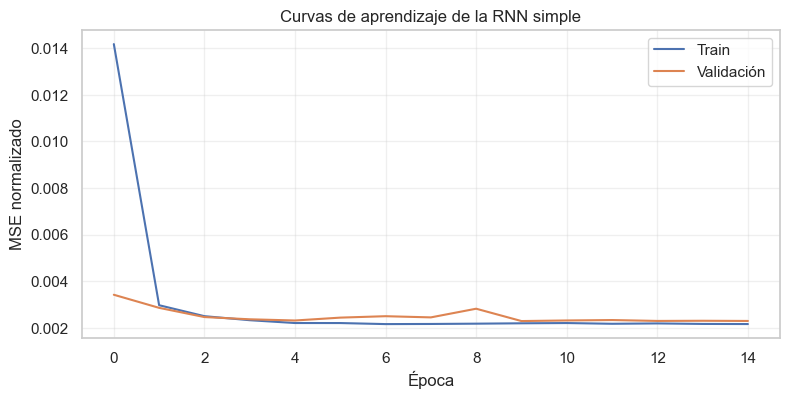

In [45]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

rnn = SimpleRNN()
history = fit(rnn, dataloader, epochs=50, patience=5)

plt.figure(figsize=(9, 4))
plt.plot(history['train_loss'], label="Train")
plt.plot(history['val_loss'], label="Validación")
plt.xlabel("Época"); plt.ylabel("MSE normalizado")
plt.title("Curvas de aprendizaje de la RNN simple")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 9. Evaluación en test y predicción del próximo día

MAE test:  1.26 °C
RMSE test: 1.73 °C


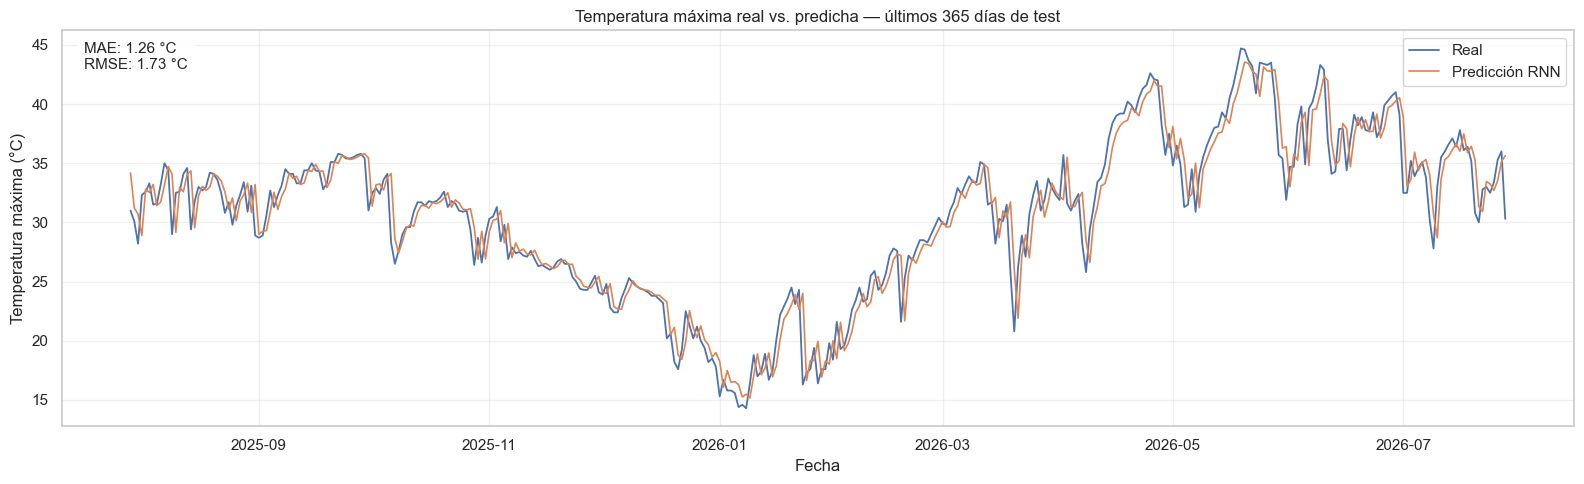

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_normalizado = predict(rnn, dataloader['test']).ravel()
y_pred = desnormalizar_temperatura(y_pred_normalizado)
y_real = desnormalizar_temperatura(Y_test.ravel())

mae = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
print(f"MAE test:  {mae:.2f} °C")
print(f"RMSE test: {rmse:.2f} °C")

ultimos_dias = min(365, len(y_real))
fig, ax = plt.subplots(figsize=(16, 5))
plt.plot(fechas_test[-ultimos_dias:], y_real[-ultimos_dias:], label="Real", linewidth=1.3)
plt.plot(fechas_test[-ultimos_dias:], y_pred[-ultimos_dias:], label="Predicción RNN", linewidth=1.2)
plt.title(f"Temperatura máxima real vs. predicha — últimos {ultimos_dias} días de test")
plt.xlabel("Fecha"); plt.ylabel("Temperatura máxima (°C)")
ax.text(
    0.015, 0.97, f"MAE: {mae:.2f} °C\nRMSE: {rmse:.2f} °C",
    transform=ax.transAxes, va="top", ha="left", fontsize=11,
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "alpha": 0.85}
)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [47]:
# Pronóstico un paso adelante después de la última fecha disponible.
ultima_ventana = valores_normalizados[-n_steps:].reshape(1, n_steps, 1)
rnn.eval()
with torch.no_grad():
    pred_siguiente_normalizada = rnn(torch.from_numpy(ultima_ventana).to(device)).cpu().numpy()[0, 0]

pred_siguiente = desnormalizar_temperatura(pred_siguiente_normalizada)
fecha_siguiente = serie_delhi["date"].iloc[-1] + pd.Timedelta(days=1)
print(f"Predicción para {fecha_siguiente.date()}: {pred_siguiente:.2f} °C de temperatura máxima")

Predicción para 2026-07-29: 30.35 °C de temperatura máxima


# Variante 2: LSTM

La preparación de datos, las ventanas y la división temporal son exactamente las mismas que en la RNN simple; solo cambia la celda recurrente.

In [48]:
class LSTM(SimpleRNN):
  def __init__(self, input_size=1, hidden_size=20, num_layers=2):
    super().__init__(input_size, hidden_size, num_layers)
    self.rnn = torch.nn.LSTM(
        input_size=input_size, hidden_size=hidden_size,
        num_layers=num_layers, batch_first=True
    )

  0%|          | 0/50 [00:00<?, ?it/s]


Early stopping en la época 13. Mejor val_loss: 0.00234


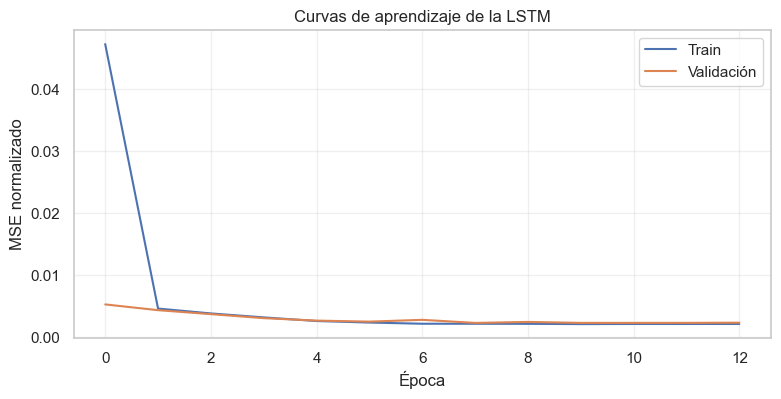

In [49]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

lstm = LSTM()
history_lstm = fit(lstm, dataloader, epochs=50, patience=5)

plt.figure(figsize=(9, 4))
plt.plot(history_lstm['train_loss'], label="Train")
plt.plot(history_lstm['val_loss'], label="Validación")
plt.xlabel("Época"); plt.ylabel("MSE normalizado")
plt.title("Curvas de aprendizaje de la LSTM")
plt.legend(); plt.grid(alpha=0.3); plt.show()

MAE LSTM:  1.27 °C
RMSE LSTM: 1.74 °C


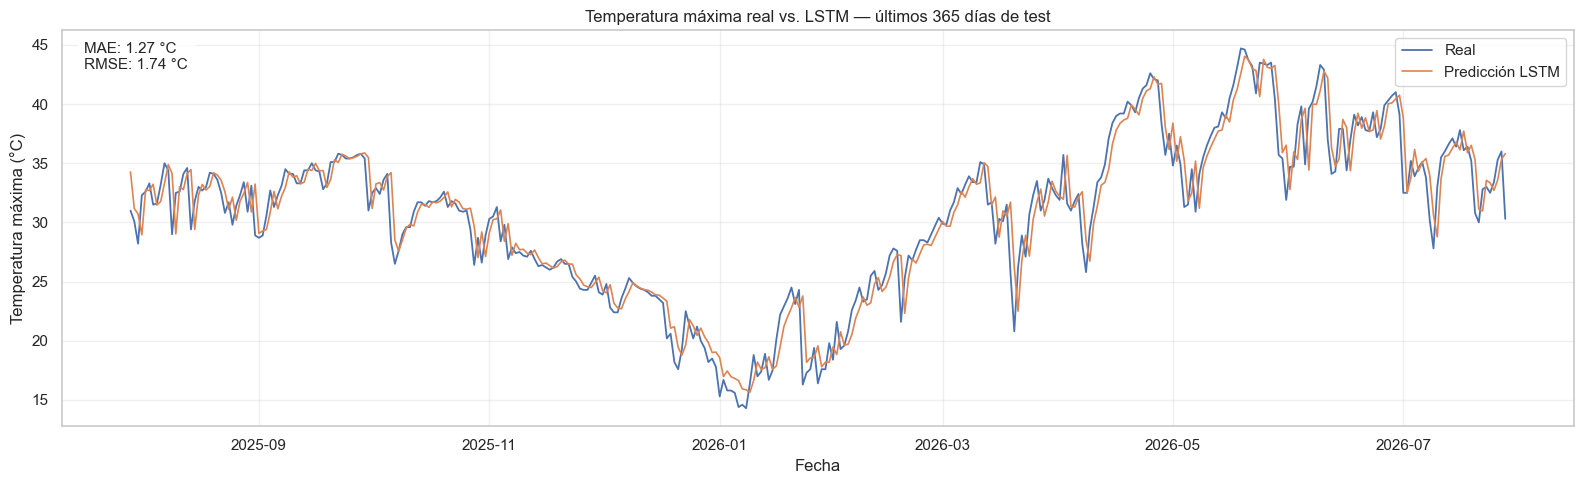

In [50]:
y_pred_lstm_normalizado = predict(lstm, dataloader['test']).ravel()
y_pred_lstm = desnormalizar_temperatura(y_pred_lstm_normalizado)

mae_lstm = mean_absolute_error(y_real, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_real, y_pred_lstm))
print(f"MAE LSTM:  {mae_lstm:.2f} °C")
print(f"RMSE LSTM: {rmse_lstm:.2f} °C")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(fechas_test[-ultimos_dias:], y_real[-ultimos_dias:], label="Real", linewidth=1.3)
ax.plot(fechas_test[-ultimos_dias:], y_pred_lstm[-ultimos_dias:], label="Predicción LSTM", linewidth=1.2)
ax.set_title(f"Temperatura máxima real vs. LSTM — últimos {ultimos_dias} días de test")
ax.set_xlabel("Fecha"); ax.set_ylabel("Temperatura máxima (°C)")
ax.text(0.015, 0.97, f"MAE: {mae_lstm:.2f} °C\nRMSE: {rmse_lstm:.2f} °C",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "alpha": 0.85})
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [51]:
lstm.eval()
with torch.no_grad():
    pred_lstm_normalizada = lstm(torch.from_numpy(ultima_ventana).to(device)).cpu().numpy()[0, 0]
pred_siguiente_lstm = desnormalizar_temperatura(pred_lstm_normalizada)
print(f"Predicción LSTM para {fecha_siguiente.date()}: {pred_siguiente_lstm:.2f} °C")

Predicción LSTM para 2026-07-29: 30.15 °C


# Variante 3: GRU

La GRU conserva una memoria controlada mediante compuertas, pero utiliza una estructura más compacta que la LSTM.

In [52]:
class GRU(SimpleRNN):
  def __init__(self, input_size=1, hidden_size=20, num_layers=2):
    super().__init__(input_size, hidden_size, num_layers)
    self.rnn = torch.nn.GRU(
        input_size=input_size, hidden_size=hidden_size,
        num_layers=num_layers, batch_first=True
    )

  0%|          | 0/50 [00:00<?, ?it/s]


Early stopping en la época 10. Mejor val_loss: 0.00234


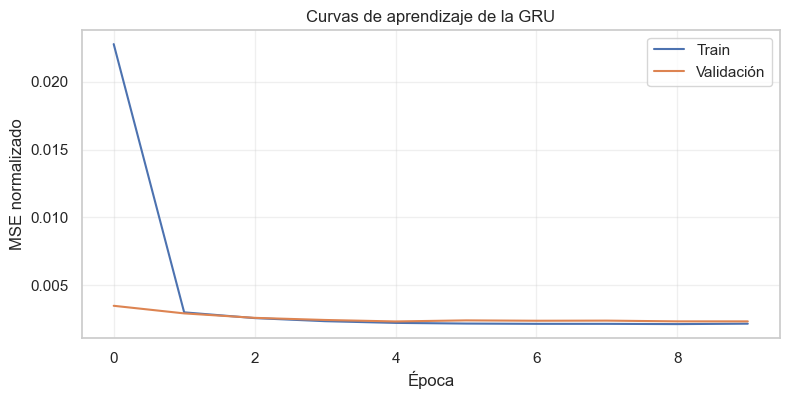

In [53]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

gru = GRU()
history_gru = fit(gru, dataloader, epochs=50, patience=5)

plt.figure(figsize=(9, 4))
plt.plot(history_gru['train_loss'], label="Train")
plt.plot(history_gru['val_loss'], label="Validación")
plt.xlabel("Época"); plt.ylabel("MSE normalizado")
plt.title("Curvas de aprendizaje de la GRU")
plt.legend(); plt.grid(alpha=0.3); plt.show()

MAE GRU:  1.27 °C
RMSE GRU: 1.75 °C


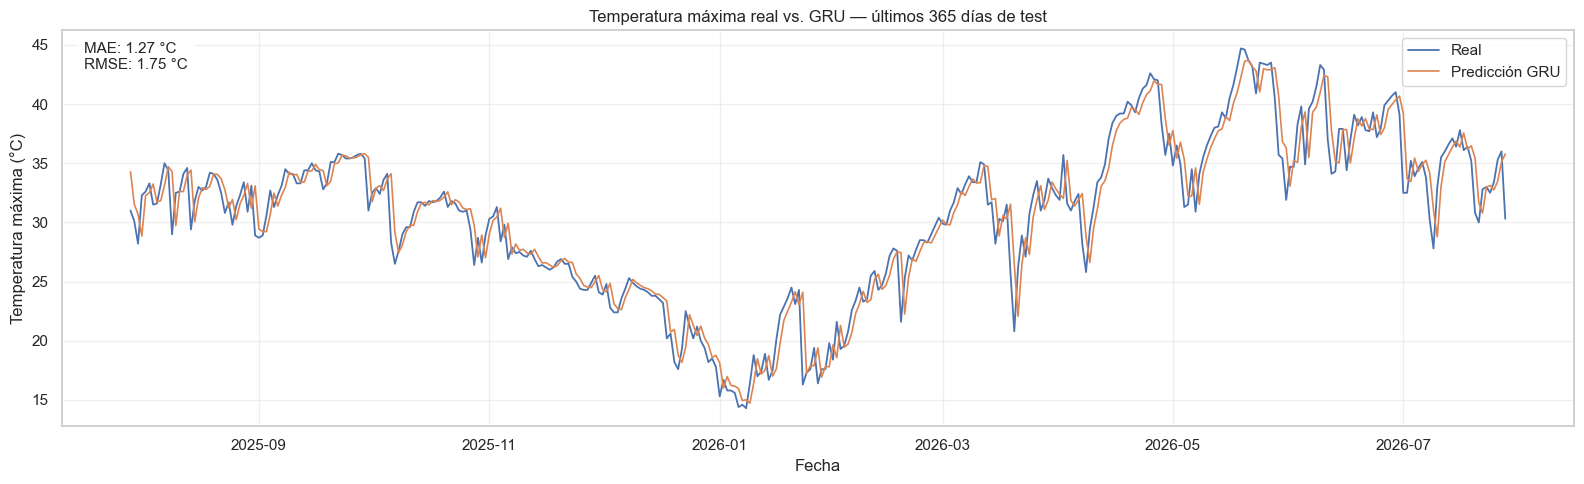

In [54]:
y_pred_gru_normalizado = predict(gru, dataloader['test']).ravel()
y_pred_gru = desnormalizar_temperatura(y_pred_gru_normalizado)

mae_gru = mean_absolute_error(y_real, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_real, y_pred_gru))
print(f"MAE GRU:  {mae_gru:.2f} °C")
print(f"RMSE GRU: {rmse_gru:.2f} °C")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(fechas_test[-ultimos_dias:], y_real[-ultimos_dias:], label="Real", linewidth=1.3)
ax.plot(fechas_test[-ultimos_dias:], y_pred_gru[-ultimos_dias:], label="Predicción GRU", linewidth=1.2)
ax.set_title(f"Temperatura máxima real vs. GRU — últimos {ultimos_dias} días de test")
ax.set_xlabel("Fecha"); ax.set_ylabel("Temperatura máxima (°C)")
ax.text(0.015, 0.97, f"MAE: {mae_gru:.2f} °C\nRMSE: {rmse_gru:.2f} °C",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "alpha": 0.85})
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [55]:
gru.eval()
with torch.no_grad():
    pred_gru_normalizada = gru(torch.from_numpy(ultima_ventana).to(device)).cpu().numpy()[0, 0]
pred_siguiente_gru = desnormalizar_temperatura(pred_gru_normalizada)
print(f"Predicción GRU para {fecha_siguiente.date()}: {pred_siguiente_gru:.2f} °C")

Predicción GRU para 2026-07-29: 31.01 °C


# Comparación final: pronóstico de los próximos tres días

Cada modelo genera tres días de forma recursiva: la predicción de un día se incorpora a la ventana para calcular el siguiente. Es una prueba más exigente que la predicción de un solo paso.

Edita únicamente `valores_reales_3_dias` cuando conozcas las temperaturas máximas reales correspondientes a las fechas mostradas.

In [56]:
def predecir_recursivo(model, ventana_inicial, n_dias=3):
    model.eval()
    ventana = ventana_inicial.astype(np.float32).copy().reshape(-1)
    predicciones = []

    with torch.no_grad():
        for _ in range(n_dias):
            entrada = torch.from_numpy(ventana.reshape(1, -1, 1)).to(
                device=device, dtype=torch.float32
            )
            pred = np.float32(model(entrada).cpu().numpy().item())
            predicciones.append(pred)
            # concatenate conserva float32; np.append promovía la ventana a float64.
            ventana = np.concatenate(
                [ventana[1:], np.asarray([pred], dtype=np.float32)]
            ).astype(np.float32, copy=False)

    return desnormalizar_temperatura(
        np.asarray(predicciones, dtype=np.float32)
    )

ventana_final = valores_normalizados[-n_steps:]
pred_3_rnn = predecir_recursivo(rnn, ventana_final, n_dias=3)
pred_3_lstm = predecir_recursivo(lstm, ventana_final, n_dias=3)
pred_3_gru = predecir_recursivo(gru, ventana_final, n_dias=3)
fechas_futuras = pd.date_range(serie_delhi["date"].iloc[-1] + pd.Timedelta(days=1), periods=3)

pd.DataFrame({
    "fecha": fechas_futuras,
    "RNN simple (°C)": pred_3_rnn,
    "LSTM (°C)": pred_3_lstm,
    "GRU (°C)": pred_3_gru
}).round(2)

C:\Users\aaran\AppData\Local\Temp\ipykernel_16736\3830611532.py:33: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  }).round(2)


,fecha,RNN simple (°C),LSTM (°C),GRU (°C)
0,2026-07-29,30.35,30.15,31.010000
1,2026-07-30,30.98,30.85,31.540001
2,2026-07-31,31.42,31.43,31.790001


In [ ]:
# INTRODUCE AQUÍ las temperaturas máximas reales de las tres fechas, en el mismo orden.
# Ejemplo cuando tengas los datos: valores_reales_3_dias = [31.2, 32.5, 30.8]
valores_reales_3_dias = [33.0, 35.0, 34.0]

comparacion_3_dias = pd.DataFrame({
    "fecha": fechas_futuras,
    "Real": valores_reales_3_dias,
    "RNN simple": pred_3_rnn,
    "LSTM": pred_3_lstm,
    "GRU": pred_3_gru
})
comparacion_3_dias.round(2)

C:\Users\aaran\AppData\Local\Temp\ipykernel_16736\626954436.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  comparacion_3_dias.round(2)


,fecha,Real,RNN simple,LSTM,GRU
0,2026-07-29,32.0,30.35,30.15,31.010000
1,2026-07-30,32.0,30.98,30.85,31.540001
2,2026-07-31,34.0,31.42,31.43,31.790001


Modelo más acertado en estos tres días: GRU (MAE = 1.22 °C)


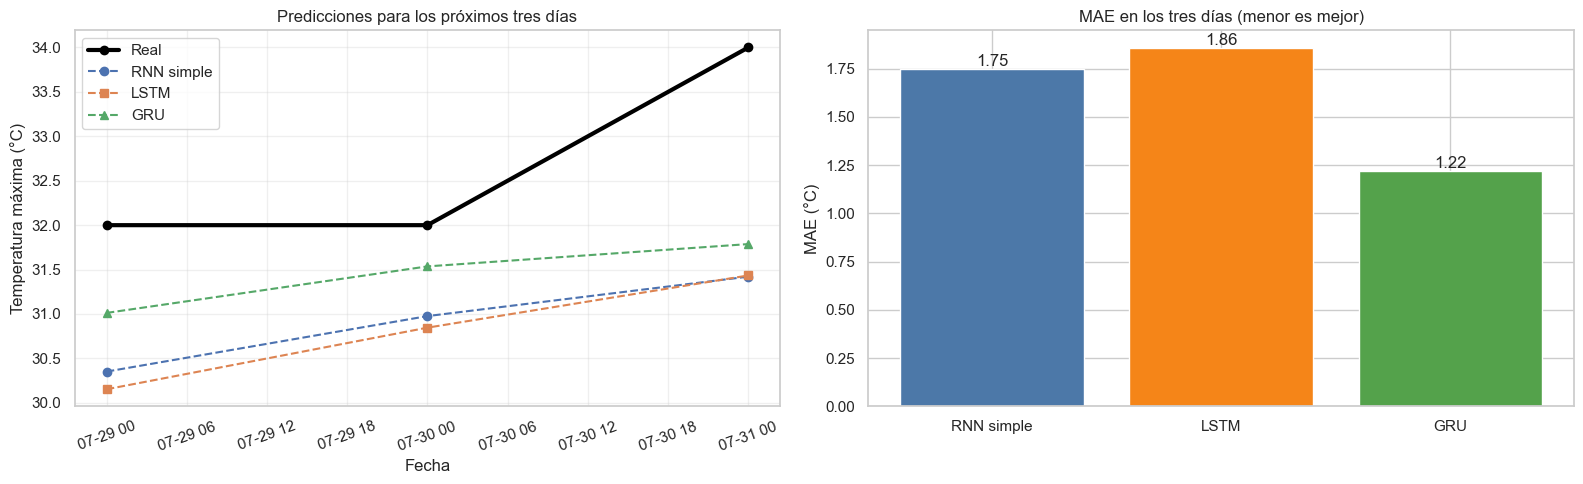

In [58]:
valores_reales = np.asarray(valores_reales_3_dias, dtype=float)
hay_valores_reales = np.isfinite(valores_reales).all()

if hay_valores_reales:
    errores_mae_3_dias = {
        "RNN simple": mean_absolute_error(valores_reales, pred_3_rnn),
        "LSTM": mean_absolute_error(valores_reales, pred_3_lstm),
        "GRU": mean_absolute_error(valores_reales, pred_3_gru)
    }
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    axes = [ax]
    print("Introduce los tres valores reales para calcular y comparar los errores.")

ax_pred = axes[0]
if hay_valores_reales:
    ax_pred.plot(fechas_futuras, valores_reales, "o-", linewidth=3, color="black", label="Real")
ax_pred.plot(fechas_futuras, pred_3_rnn, "o--", label="RNN simple")
ax_pred.plot(fechas_futuras, pred_3_lstm, "s--", label="LSTM")
ax_pred.plot(fechas_futuras, pred_3_gru, "^--", label="GRU")
ax_pred.set_title("Predicciones para los próximos tres días")
ax_pred.set_xlabel("Fecha"); ax_pred.set_ylabel("Temperatura máxima (°C)")
ax_pred.tick_params(axis="x", rotation=20)
ax_pred.grid(alpha=0.3); ax_pred.legend()

if hay_valores_reales:
    nombres = list(errores_mae_3_dias.keys())
    errores = list(errores_mae_3_dias.values())
    colores = ["#4C78A8", "#F58518", "#54A24B"]
    axes[1].bar(nombres, errores, color=colores)
    axes[1].set_title("MAE en los tres días (menor es mejor)")
    axes[1].set_ylabel("MAE (°C)")
    for i, error in enumerate(errores):
        axes[1].text(i, error, f"{error:.2f}", ha="center", va="bottom")
    mejor_modelo = min(errores_mae_3_dias, key=errores_mae_3_dias.get)
    print(f"Modelo más acertado en estos tres días: {mejor_modelo} "
          f"(MAE = {errores_mae_3_dias[mejor_modelo]:.2f} °C)")

plt.tight_layout(); plt.show()

# Métricas finales de los modelos

Este problema es de **regresión**, porque se predice una temperatura continua. Por ello no corresponden accuracy, precision, recall, F1 ni ROC-AUC. Se utilizan MAE, RMSE, R² y MAPE. También se incluye un baseline de persistencia que supone que la temperatura máxima de mañana será igual a la de hoy.

In [59]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Baseline: usar como predicción la temperatura del último día de cada ventana.
y_pred_baseline = desnormalizar_temperatura(X_test[:, -1, 0])

def calcular_metricas_regresion(y_true, y_pred):
    return {
        "MAE (°C)": mean_absolute_error(y_true, y_pred),
        "RMSE (°C)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100
    }

predicciones_modelos = {
    "Baseline": y_pred_baseline,
    "RNN simple": y_pred,
    "LSTM": y_pred_lstm,
    "GRU": y_pred_gru
}

metricas_finales = pd.DataFrame({
    nombre: calcular_metricas_regresion(y_real, prediccion)
    for nombre, prediccion in predicciones_modelos.items()
}).T

mae_baseline = metricas_finales.loc["Baseline", "MAE (°C)"]
metricas_finales["Mejora MAE vs. baseline (%)"] = (
    (mae_baseline - metricas_finales["MAE (°C)"]) / mae_baseline * 100
)

metricas_finales.round(3)

,MAE (°C),RMSE (°C),R²,MAPE (%),Mejora MAE vs. baseline (%)
Baseline,1.287,1.785,0.932,4.480,0.000
RNN simple,1.263,1.732,0.936,4.401,1.811
LSTM,1.267,1.740,0.936,4.445,1.571
GRU,1.275,1.750,0.935,4.440,0.924


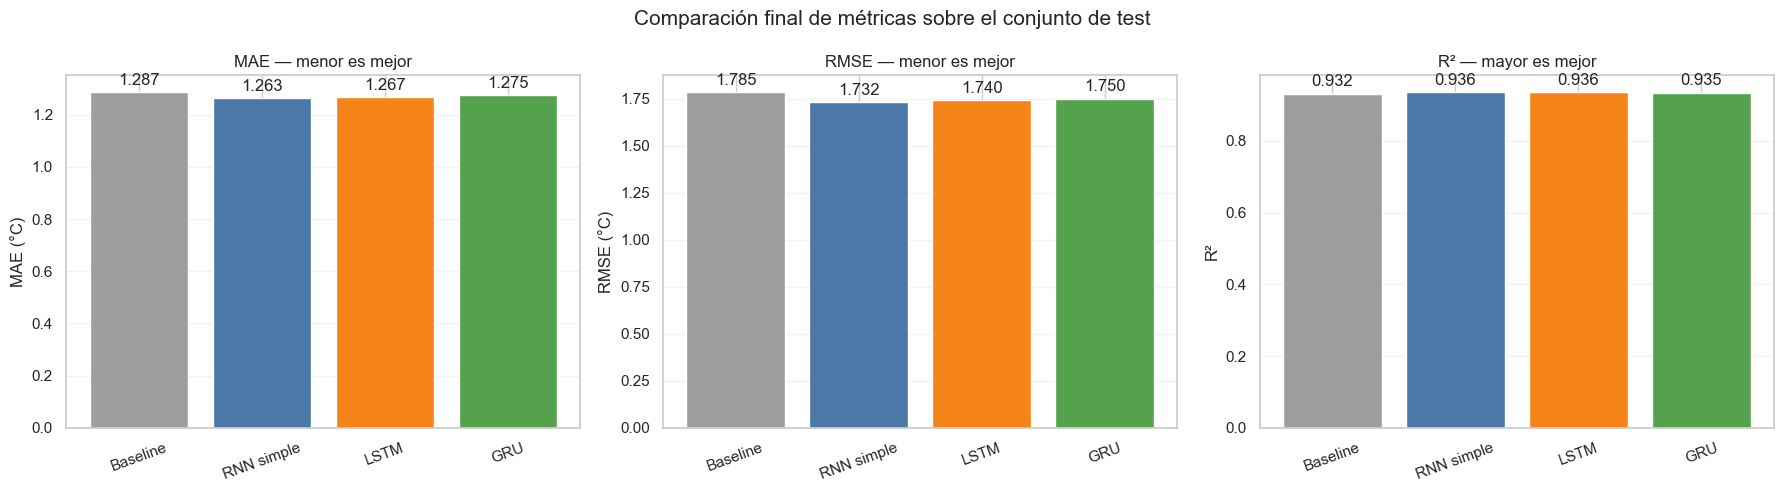

Mejor modelo según MAE de test: RNN simple


In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores_modelos = ["#9E9E9E", "#4C78A8", "#F58518", "#54A24B"]

for ax, metrica, titulo in zip(
    axes,
    ["MAE (°C)", "RMSE (°C)", "R²"],
    ["MAE — menor es mejor", "RMSE — menor es mejor", "R² — mayor es mejor"]
):
    barras = ax.bar(metricas_finales.index, metricas_finales[metrica], color=colores_modelos)
    ax.set_title(titulo)
    ax.set_ylabel(metrica)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(barras, fmt="%.3f", padding=3)

plt.suptitle("Comparación final de métricas sobre el conjunto de test", fontsize=15)
plt.tight_layout(); plt.show()

mejor_modelo_test = metricas_finales.drop(index="Baseline")["MAE (°C)"].idxmin()
print(f"Mejor modelo según MAE de test: {mejor_modelo_test}")